# Customer Segmentation Using K-Means Clustering

## Introduction

Customer segmentation is a fundamental business strategy that involves dividing customers into distinct groups based on shared characteristics and purchasing behavior. By understanding these groups, businesses can develop targeted marketing campaigns, improve customer satisfaction, optimize resource allocation, and increase overall profitability.

In this project, the **Mall Customers** dataset is analyzed to identify meaningful customer segments using the **K-Means Clustering** algorithm, an unsupervised machine learning technique. The dataset contains demographic and behavioral information, including customer age, gender, annual income, and spending score.

The project begins with data cleaning and exploratory data analysis (EDA) to understand the dataset and uncover important patterns. Relevant features are then selected and standardized before applying the K-Means algorithm to group customers into clusters with similar characteristics.

The primary objectives of this project are to:

* Explore the demographic and spending characteristics of mall customers.
* Identify natural customer segments using K-Means clustering.
* Interpret each customer segment based on its defining characteristics.
* Provide business recommendations that can support targeted marketing strategies and improve customer engagement.

The insights obtained from this analysis can help businesses better understand their customer base, personalize marketing efforts, and make more informed, data-driven decisions.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Importing Required Libraries

The necessary Python libraries for data manipulation, visualization, and analysis are imported.

In [2]:
df = pd.read_csv('data/store_customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


### Loading the Dataset

The customer store Dataset is loaded into the pandas dateframe for analysis. We can also see a display of the first 5 columns of the dataset and how the data looks like.

In [3]:
df.shape

(1000, 5)

### Data Shape

In this dataset, we can see that it has 5 columns and 1000 records or rows

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


### Dataset Overview

Basic operations were performed on this dataset using the describe and info function to show the count, mean, std, and 5 different percentiles.

### Observation

The standard deviation lower than the mean, indicating a relatively low level of variability. For the age, this shows that most customers fall within a relatively narrow age range. The spending score exhibits greater variability, suggesting significant differences in customer purchasing behavior. This variation makes spending score an informative feature for customer segmentation

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 40.3 KB


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

### Missing Value Check

The datasett was examined for missing(null) values and we can see that we have quite a little amount of null values. The ratio of these values to the entire dataset so it would mae sense for us to fill these values

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

### Handle Missing Values

To handle the missing values in Age, Annual Income and Spending score we would fill them with their median. This is because they are numerical values and also because the mean is easily affected by out liers

For the missing value in Gender we would fill them with the mode because gender is a categorical column

In [8]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Missing Value Recheck

From this we can see that we have corrected and mede there not to be any missing value

In [9]:
df.duplicated().sum()

np.int64(0)

### Duplicate Value Check
A check was performed to identify duplicate records in the dataset. The analysis showed that there were no duplicate entries present. Therefore, no records needed to be removed, ensuring that each observation in the dataset is unique.

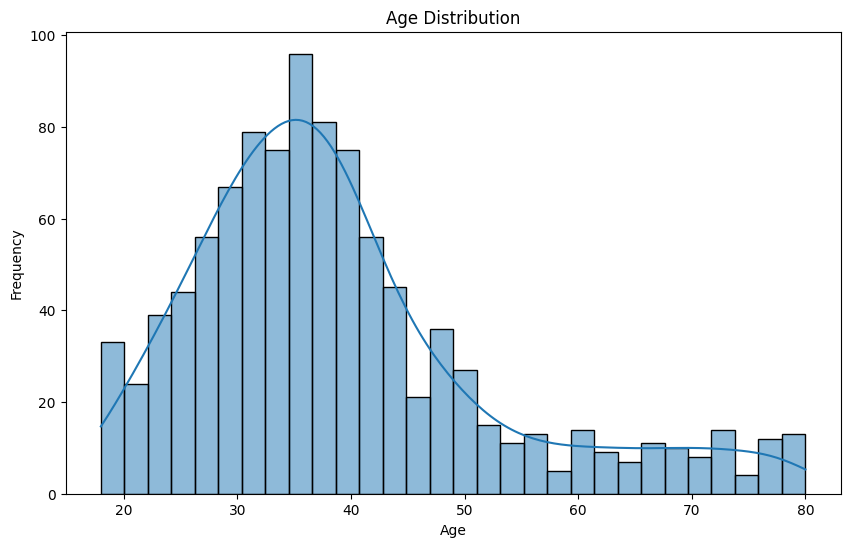

In [10]:
# age distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Age Distribution Analysis

The distribution of customer ages is **slightly right-skewed**, indicating that the majority of customers are relatively younger, while a smaller number of older customers extend the distribution toward higher ages. This suggests that the mall primarily attracts younger and middle-aged individuals, with comparatively fewer elderly customers.

The absence of extreme peaks or irregular patterns indicates a fairly balanced age distribution despite the slight positive skew. This demographic insight may help businesses tailor products and marketing campaigns toward the age groups that make up the largest proportion of customers.


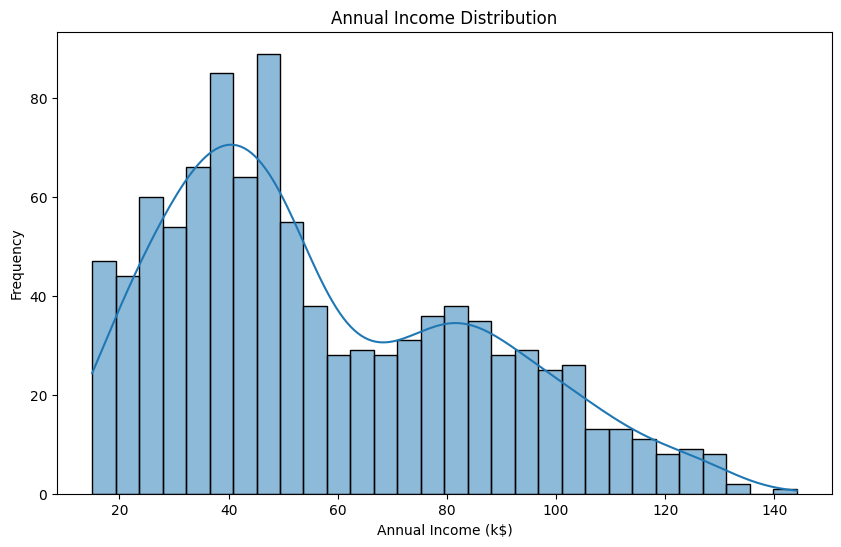

In [11]:
# income distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Annual Income (k$)'], bins=30, kde=True)
plt.title('Annual Income Distribution')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')
plt.show()

### Annual Income Distribution Analysis

The distribution of customers' annual income is **slightly right-skewed**, indicating that while most customers fall within the lower to middle-income range, a smaller proportion of customers have relatively higher incomes. The positive skew suggests that high-income customers are present but are less common.

Additionally, the distribution is **not perfectly uniform**, with a noticeable increase in customer frequency within the **70–80k annual income range**. This indicates that a relatively larger group of customers belongs to this income bracket, making it one of the more prominent income segments in the dataset.

Overall, the income distribution suggests that the mall serves customers from a wide range of income levels, with a concentration around the middle-income range and fewer customers in the highest income categories. This variation in income levels makes annual income an important feature for customer segmentation and targeted marketing strategies.


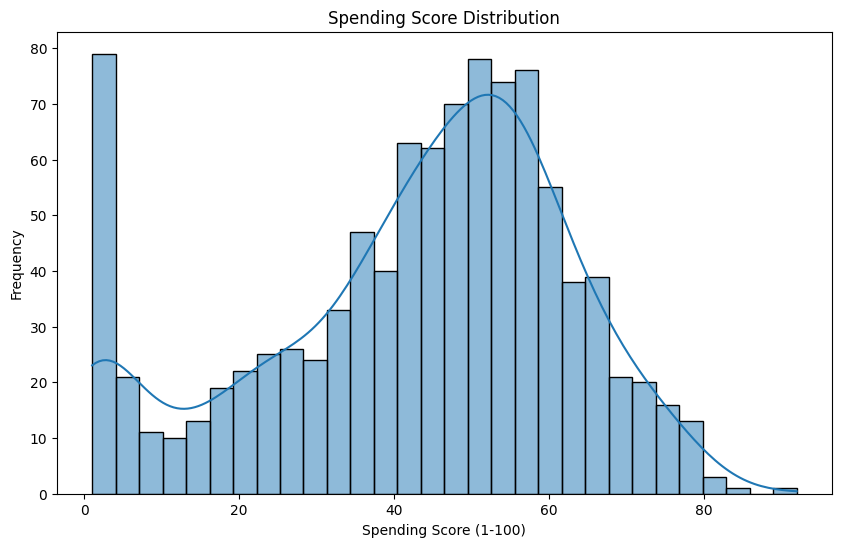

In [12]:
# spending score distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Spending Score (1-100)'], bins=30, kde=True)
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Frequency')
plt.show()

### Spending Score Distribution Analysis

The distribution of customers' spending scores is **slightly left-skewed (negatively skewed)**, indicating that a larger proportion of customers have moderate to high spending scores, while fewer customers have relatively low spending scores. This suggests that many customers actively spend at the mall, with only a small proportion exhibiting low purchasing activity.

Additionally, the distribution is **not perfectly uniform**, displaying a noticeable concentration of customers with spending scores close to **0** before becoming more evenly distributed across the remaining score range. This indicates the presence of a small group of customers who spend very little compared to the rest of the customer base.

Overall, the spending score distribution demonstrates that the mall serves customers with a wide range of purchasing behaviors. The observed variation in spending patterns makes **Spending Score** an important feature for customer segmentation, as it helps distinguish between low-, moderate-, and high-spending customers and supports the development of targeted marketing strategies.


In [13]:
# Spending difference in gender
Total_spending_in_gender = df.groupby('Gender')['Spending Score (1-100)'].count()
Total_spending_in_gender

Gender
F    525
M    475
Name: Spending Score (1-100), dtype: int64

### Spending Score Distribution by Gender

The distribution of spending scores across male and female customers appears relatively balanced, indicating that both genders contribute similarly to the overall customer base. While there may be slight variations in the frequency of certain spending score ranges, there is no strong visual evidence that one gender consistently spends more than the other.

This suggests that gender alone may not be a significant factor in determining customer spending behavior. Additional variables, such as age and annual income, should be considered alongside gender to better understand customer purchasing patterns.


In [14]:
# mean spending in gender
Mean_spending_in_gender = df.groupby('Gender')['Spending Score (1-100)'].mean()
Mean_spending_in_gender

Gender
F    42.285714
M    43.098947
Name: Spending Score (1-100), dtype: float64

### Average Spending Score in Gender

This shows the average spending score in each gender and it is seen that the average spending score is relatively balanced and equal. It can therefor be said that the gender of the customer doesnt really affect the spending score

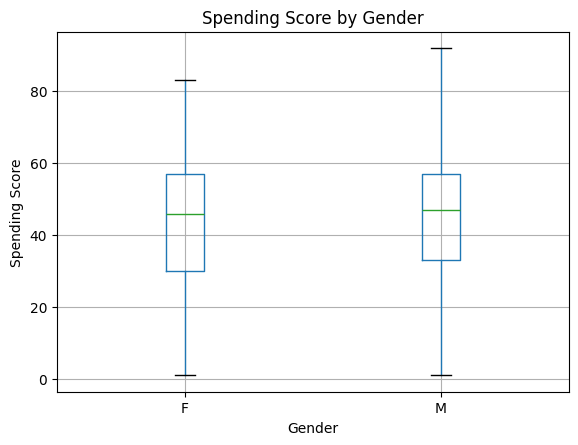

In [15]:
df.boxplot(column="Spending Score (1-100)", by="Gender")
plt.title("Spending Score by Gender")
plt.suptitle("")  # Removes the extra title added by pandas
plt.xlabel("Gender")
plt.ylabel("Spending Score")
plt.show()

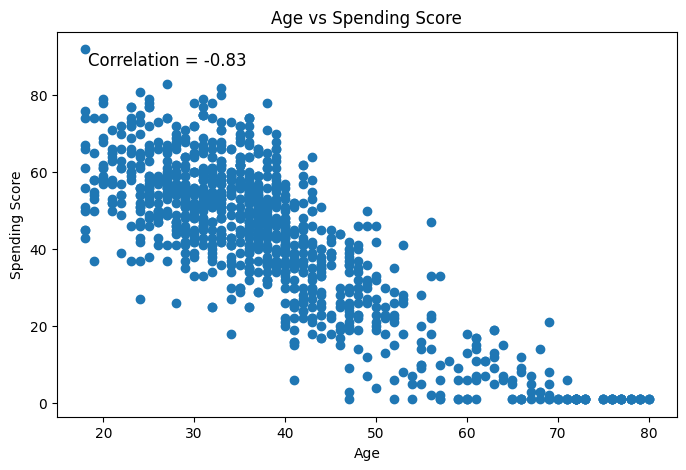

In [16]:
# Correlation between age and spending score
corr = df["Age"].corr(df["Spending Score (1-100)"])

plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Spending Score (1-100)"])

plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending Score")

plt.text(
    0.05, 0.95,
    f"Correlation = {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.show()

### Correlation Between Age and Spending Score

The analysis reveals a **strong negative correlation** between **Age** and **Spending Score**, indicating that spending tends to decrease as customer age increases. In other words, younger customers generally have higher spending scores, while older customers are more likely to have lower spending scores.

This relationship suggests that age is an important factor influencing customer purchasing behavior. Younger customers appear to be more actively engaged in shopping, whereas older customers exhibit relatively lower spending activity.

From a business perspective, these findings can help guide marketing strategies. Promotions, loyalty programs, and product offerings can be tailored to attract and retain younger, high-spending customers while also developing targeted campaigns to encourage greater engagement among older customer segments.


Text(0.05, 0.05, 'Correlation = -0.841347')

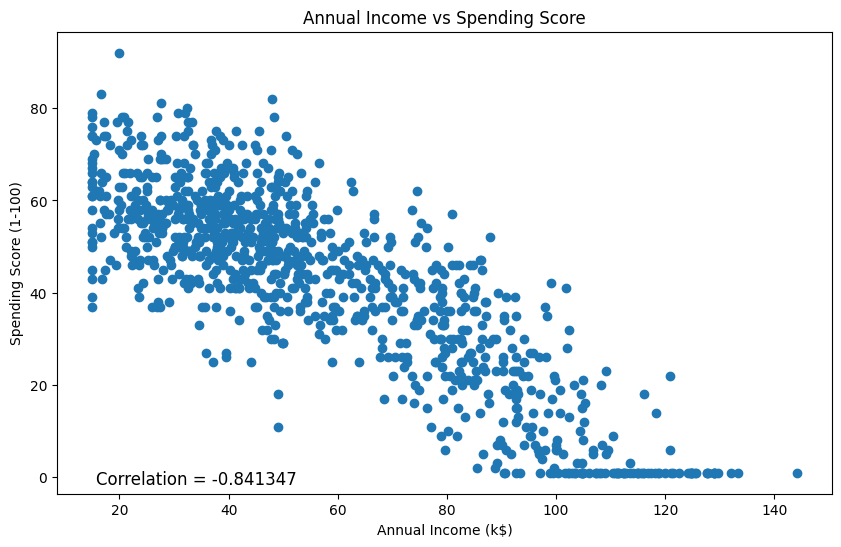

In [17]:
# correlation between income and spending score
corr_income = df["Annual Income (k$)"].corr(df["Spending Score (1-100)"])

plt.figure(figsize=(10,6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.text(
  0.05, 0.05,
  f"Correlation = {corr_income:2f}",
  transform=plt.gca().transAxes,
  fontsize=12,
  verticalalignment='top'
)


### Correlation Between Annual Income and Spending Score

The analysis indicates a strong negative correlation between annual income and spending score, suggesting that customers with higher annual incomes tend to have lower spending scores. Conversely, customers with lower annual incomes generally exhibit higher spending scores.

From a business perspective, this relationship suggests that high-income customers may not be fully engaged with the mall's offerings. Targeted marketing campaigns, personalized promotions, and loyalty programs could be used to encourage greater spending among these customers.

In [18]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

### Feature Selection

Feature selection is an important preprocessing step in machine learning that involves choosing the variables most relevant to the analysis. For this project, **Annual Income (k$)** and **Spending Score (1–100)** were selected as the input features for the K-Means clustering algorithm.

These features were chosen because they provide valuable information about customers' purchasing power and spending behavior. By clustering customers based on these characteristics, the model can identify distinct customer segments that share similar financial and spending patterns.

Other variables, such as **Customer ID**, were excluded because they serve only as unique identifiers and do not contribute meaningful information for clustering. Similarly, **Gender** and **Age** were not included in the initial model to focus the segmentation on customer spending behavior.


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

### Feature Scaling

Before applying the K-Means clustering algorithm, the selected features were standardized using **StandardScaler**. Feature scaling is an important preprocessing step because K-Means groups observations based on the distance between data points.

The selected features, **Annual Income (k$)** and **Spending Score (1–100)**, are measured on different scales. Without scaling, the feature with the larger numerical values could disproportionately influence the clustering results.

StandardScaler transforms each feature so that it has a **mean of 0** and a **standard deviation of 1**. This ensures that both features contribute equally to the distance calculations performed by the K-Means algorithm, leading to more balanced and meaningful customer segments.


In [20]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
  kmeans = KMeans(
    n_clusters=k,
    random_state=42
  )
  kmeans.fit(x_scaled)
  inertia.append(kmeans.inertia_)

## Determining the Optimal Number of Clusters (Elbow Method)

### Elbow Method

Before training the final K-Means clustering model, it is important to determine the optimal number of clusters (**K**). In this project, the **Elbow Method** was used for this purpose.

The Elbow Method involves training multiple K-Means models using different numbers of clusters, ranging from **1 to 10**. For each model, the **inertia** value is calculated. Inertia measures how closely data points are grouped around their assigned cluster centroids. Lower inertia values indicate more compact clusters.

As the number of clusters increases, inertia naturally decreases because data points are divided into smaller groups. However, after a certain point, the improvement becomes much smaller. This point, known as the **elbow**, represents the optimal number of clusters, where additional clusters provide only marginal improvements while increasing model complexity.

The selected value of **K** was then used to train the final K-Means clustering model for customer segmentation.

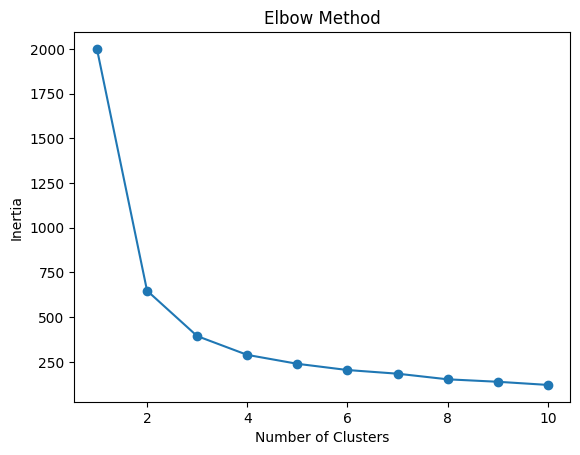

In [21]:
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### Elbow Method Visualization

The Elbow Method was used to determine the optimal number of clusters for the K-Means clustering algorithm. The graph plots the **inertia** value against the number of clusters (**K**) ranging from 1 to 10.

Inertia measures the total within-cluster variation by calculating the sum of the squared distances between each data point and its assigned cluster centroid. As the number of clusters increases, the inertia decreases because data points are grouped into smaller, more compact clusters.

The objective is to identify the point where the rate of decrease in inertia begins to slow significantly, forming an **"elbow"** in the graph. This point represents the optimal number of clusters, where adding additional clusters results in only marginal improvements while increasing the complexity of the model.

From the elbow plot, the optimal number of clusters was identified as **4**, as this point provides a suitable balance between minimizing inertia and maintaining a simple, interpretable clustering model.


In [22]:
kmeans4 = KMeans(n_clusters=4, random_state=42)
df["Cluster4"] = kmeans4.fit_predict(x_scaled)


## Training the K-Means Clustering Model

### Model Training

After determining the optimal number of clusters using the Elbow Method, the final K-Means clustering model was trained using **4 clusters**. The algorithm was applied to the standardized feature set consisting of **Annual Income (k$)** and **Spending Score (1–100)**.

During training, K-Means grouped customers into four distinct clusters by minimizing the distance between each customer and the centroid of its assigned cluster. The algorithm iteratively updated the cluster centroids until the assignments stabilized, resulting in compact and well-defined customer segments.

The predicted cluster labels were then added to the original dataset as a new column named **Cluster4**. These labels enable further analysis, visualization, and interpretation of each customer segment, providing valuable insights into customer behavior and supporting data-driven business decision-making.

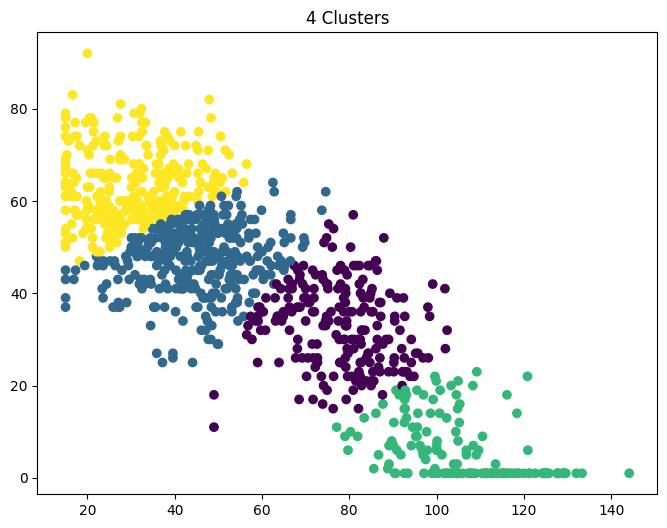

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster4']
)
plt.title("4 Clusters")
plt.show()

## Cluster Visualization

### Visualizing Customer Segments

To better understand the customer segments identified by the K-Means algorithm, the clusters were visualized using a two-dimensional scatter plot. The plot displays **Annual Income (k$)** on the x-axis and **Spending Score (1–100)** on the y-axis, with each point representing an individual customer.

Different colors were used to distinguish the four clusters, allowing the similarities and differences between customer groups to be observed visually. Customers assigned to the same cluster share similar spending and income characteristics, while those in different clusters exhibit distinct behavioral patterns.

The visualization demonstrates that the K-Means algorithm successfully separated customers into meaningful groups based on their purchasing power and spending behavior. These clearly defined clusters provide valuable insights that can support customer segmentation, targeted marketing campaigns, and strategic business decision-making.

In [24]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(x_scaled)

df.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,44.100917,78.090826,33.178899
1,33.550847,44.819774,47.548023
2,63.926174,105.514765,6.315436
3,28.322581,30.483154,63.318996


## Cluster Interpretation

### Analyzing Customer Segments

After training the K-Means model, each customer was assigned to one of the four identified clusters. To better understand the characteristics of these customer segments, the average **Age**, **Annual Income (k$)**, and **Spending Score (1–100)** were calculated for each cluster.

Computing the mean values for these features provides a clear summary of the typical customer within each segment. This makes it possible to identify patterns such as which clusters consist of younger or older customers, higher- or lower-income individuals, and customers with varying spending behaviors.

The results of this analysis form the basis for interpreting each cluster and assigning meaningful business labels. These insights enable businesses to understand the characteristics of each customer segment and develop targeted marketing strategies, personalized promotions, and customer retention initiatives tailored to the needs of each group.

In [25]:
cluster_names = {
    0: "High-Income Conservative Spenders",
    1: "Regular Customers",
    2: "Wealthy Low-Spenders",
    3: "Young High-Spenders"
}

df["Cluster Name"] = df["Cluster"].map(cluster_names)

## Cluster Labeling

### Assigning Meaningful Cluster Names

The K-Means algorithm assigns each customer to a cluster using numerical labels such as **0**, **1**, **2**, and **3**. While these labels uniquely identify each cluster, they do not provide meaningful information about the characteristics of the customers within each group.

To improve the interpretability of the results, descriptive names were assigned to each cluster based on their average age, annual income, and spending score. These labels summarize the dominant characteristics of each customer segment, making the findings easier to understand and communicate.

Replacing numerical labels with descriptive names allows business stakeholders to quickly identify the nature of each customer group. For example, a segment labelled **"Young High-Spenders"** immediately conveys valuable business insight, whereas a label such as **"Cluster 3"** provides no contextual meaning.

Meaningful cluster labels also support clearer data visualization, more effective business reporting, and the development of targeted marketing strategies for each customer segment.

In [26]:
df["Cluster"].value_counts()

Cluster
1    354
3    279
0    218
2    149
Name: count, dtype: int64

### Distribution of Customers Across Clusters

The distribution of customers across the four clusters shows that the customer base is not evenly divided. **Cluster 1** is the largest segment, containing **354 customers**, followed by **Cluster 3** with **279 customers**. **Cluster 0** consists of **218 customers**, while **Cluster 2** is the smallest segment with **149 customers**.

The variation in cluster sizes indicates that some customer groups are more prevalent than others. The larger clusters represent the majority of the customer base and may require broader marketing strategies, while the smaller cluster may represent a more specialized customer segment that could benefit from targeted campaigns and personalized services.

Understanding the size of each customer segment enables businesses to allocate marketing resources more effectively and prioritize strategies based on the characteristics and importance of each group.

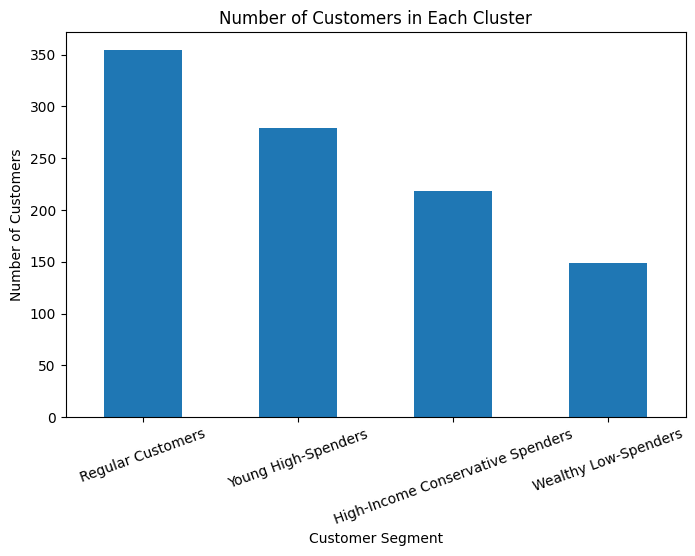

In [28]:
cluster_counts = df["Cluster Name"].value_counts()

plt.figure(figsize=(8,5))
cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

### Visualization of Customer Segments

To better understand the distribution of customers across the identified clusters, a bar chart was created to visualize the number of customers in each segment. This visualization provides a clear overview of the relative size of each customer group and highlights which segments represent the largest and smallest portions of the customer base.

The chart shows that **Cluster 1** is the largest customer segment, containing **354 customers**, followed by **Cluster 3** with **279 customers**. **Cluster 0** consists of **218 customers**, while **Cluster 2** is the smallest segment with **149 customers**.

The unequal distribution of customers across clusters suggests that certain customer profiles are more common than others. Understanding the size of each segment is important for business decision-making, as larger segments may require broader marketing initiatives, while smaller segments may benefit from more personalized and targeted strategies.

Overall, the visualization provides valuable insight into the composition of the customer base and supports the development of effective customer relationship and marketing strategies.

In [27]:
df[["Cluster", "Cluster Name"]].drop_duplicates()

,Cluster,Cluster Name
0,1,Regular Customers
2,0,High-Income Conservative Spenders
4,3,Young High-Spenders
40,2,Wealthy Low-Spenders
